# Sheetal Patil | Logistic Regression

**Problem Understanding:**\
The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone on board, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, we ask you to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).

**Objective:**\
Survival Prediction: To build a logistic regression model that accurately predicts the survival of passengers based on features such as age, gender, passenger class, and number of siblings/spouses aboard.

**Dataset Understanding:**\
**1.Passenger**- Passenger ID\
**2.Survived**- Weather Survived or not: 0 = No, 1 = Yes\
**3.Pclass**- Passenger's Ticket class: 1 = 1st, 2 = 2nd, 3 = 3rd\
**4.Name**- Name of the Passenger\
**5.Sex**- Gender of the passenger\
**6.Age**- Age in Years\
**7.SibSp**- No. of siblings or spouses aboard the Titanic\
**8.Parch**- No. of parents / children aboard the Titanic\
**9.Ticket**- Ticket number\
**10.Fare**- Passenger Ticket fare\
**11.Cabin**- Cabin number\
**12.Embarked**- Port of Embarkation:C = Cherbourg, Q = Queenstown, S = Southampton

In [2]:
# Load the libraries
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler,LabelEncoder

In [3]:
# loading or reading the data
dataframe = pd.read_csv("D:\\Work\\ExcelRCource\\Assignments\\7 Logistic Regression\\Titanic_train.csv")

### Explore the Data

In [4]:
# Printing the data
dataframe

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
dataframe.shape

(891, 12)

In [6]:
# Drop unnecessary columns
dataframe = dataframe.drop(columns=['PassengerId','Name','Ticket','Cabin'])

In [7]:
dataframe.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [8]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


Column Age and column Embarked are having null values. Also memory usage by this dataset is 55.8+ KB.

In [9]:
# finding any Duplicated data
dataframe.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
886     True
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [10]:
#Count of duplicated rows
dataframe[dataframe.duplicated()].shape

(111, 8)

**Missing values and Imputation**

In [11]:
#checking how many null values are there in the dataset using isna().
dataframe.isna().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

 Age contains 177 null values and Embarked contains 2 null values.

In [12]:
# Fill Missing Values
dataframe["Age"] = dataframe['Age'].fillna(dataframe['Age'].mean())
dataframe['Embarked'] = dataframe['Embarked'].fillna(dataframe['Embarked'].mode()[0])

We filled the null values of Age column by its mean as it is a numerical value. And we filled null values of Embarked column by its mode(most frequent value) as its a categorical value.

In [13]:
dataframe.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [14]:
dataframe.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [15]:
dataframe.describe(include = "object")

,Sex,Embarked
count,891,891
unique,2,3
top,male,S
freq,577,646


Here we can see count of male is greater than female. Also in Embarked column S (Southampton) is a most frequent value.

### Exploratory Data Analysis (EDA)

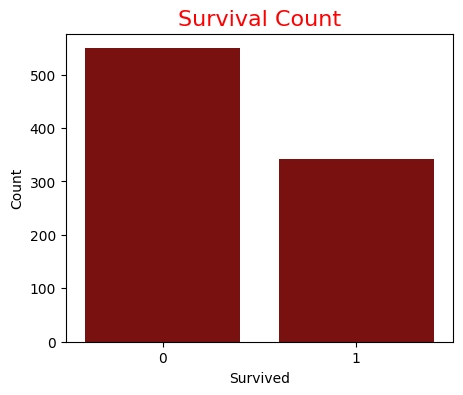

In [16]:
# visualize Survival Counts

plt.figure(figsize=(5, 4))
sns.barplot(x=dataframe['Survived'], y=dataframe['Survived'].value_counts(), color='darkred')
plt.title('Survival Count', fontsize=16, color='red')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

Not survived has greater count than survived.

Text(0.5, 1.0, 'Survival Counts by Gender')

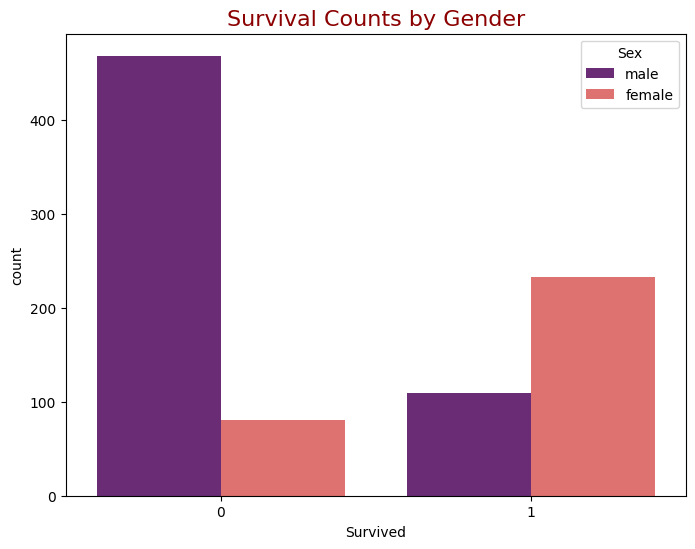

In [17]:
#  Survival Countplot vs Sex 
plt.figure(figsize= (8,6))
sns.countplot(x='Survived', hue= 'Sex', data = dataframe,palette= "magma")
plt.title("Survival Counts by Gender" ,fontsize = 16 ,color = 'darkred')

Female are having good survived count than male.

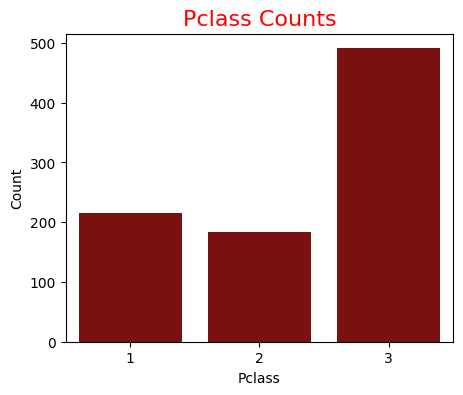

In [18]:
# visualize Pclass Counts

plt.figure(figsize=(5, 4))
sns.countplot(x=dataframe['Pclass'], color='darkred')
plt.title("Pclass Counts", fontsize=16, color='red')
plt.xlabel('Pclass')
plt.ylabel('Count')
plt.show()

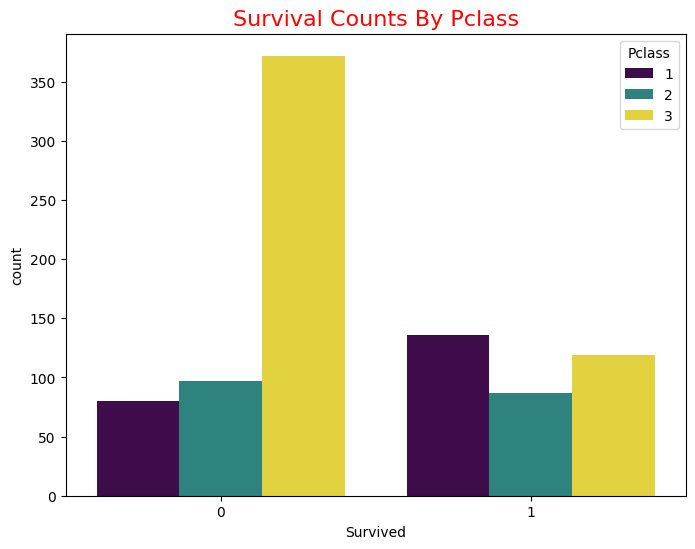

In [19]:
# Survival Counts by Pclass

plt.figure(figsize=(8,6))
sns.countplot(x=('Survived'), hue= "Pclass",data= dataframe ,palette='viridis' )
plt.title("Survival Counts By Pclass",fontsize = 16,color = 'red')
plt.show()

Not survived count is more in 3 class passengers. For survived, more count is in 1 class passengers.

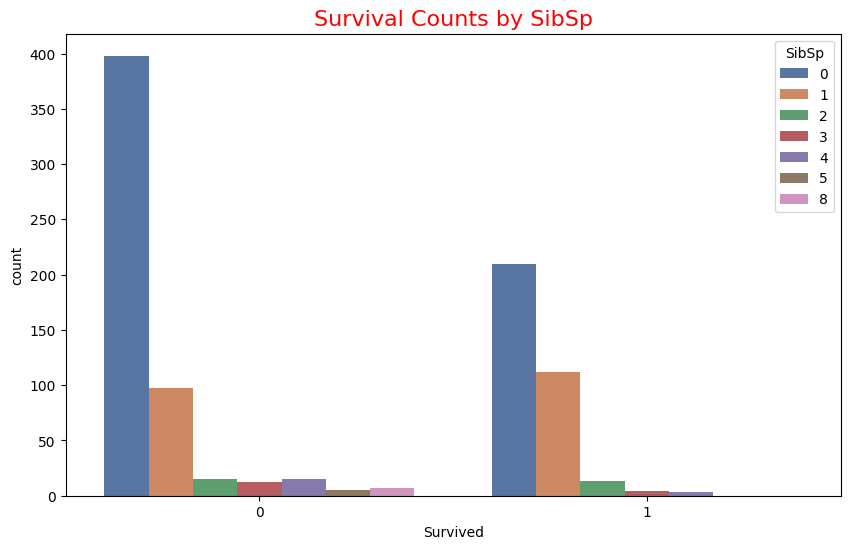

In [20]:
# Survival Counts by SibSp

plt.figure(figsize=(10,6))
sns.countplot(x = 'Survived', hue= 'SibSp', data= dataframe , palette= 'deep')
plt.title("Survival Counts by SibSp", fontsize = 16 , color = 'red')
plt.show()

In both survived and Not survived cases, 0 siblings or spouce count is much more. 

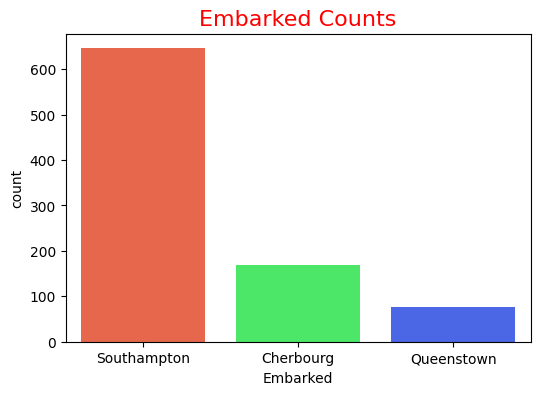

In [21]:
# Embarked Counts

plt.figure(figsize=(6,4))
sns.countplot(x= 'Embarked',hue= 'Embarked',data = dataframe, palette=['#FF5733','#33FF57','#3357FF'])
plt.xticks(ticks=[0,1,2],labels= ["Southampton","Cherbourg","Queenstown"])
plt.title("Embarked Counts", fontsize = 16, color = 'red')
plt.show()

Text(0.5, 1.0, 'Age Distribution')

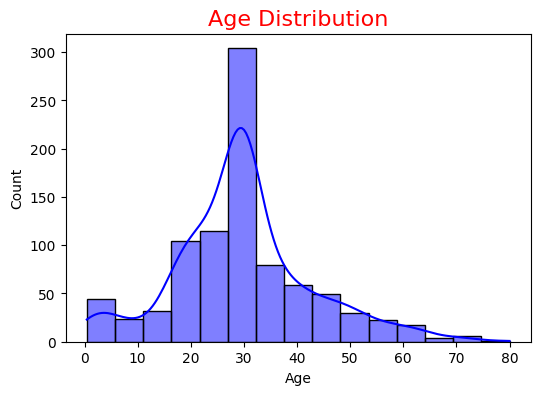

In [22]:
# Age Distribution with KDE (Kernel Density Estimation)

plt.figure(figsize=(6,4))
sns.histplot(dataframe['Age'],bins= 15, kde= True, color= 'blue')
plt.title("Age Distribution",fontsize = 16,color = 'red')

Text(0.5, 1.0, 'Fare Distribution')

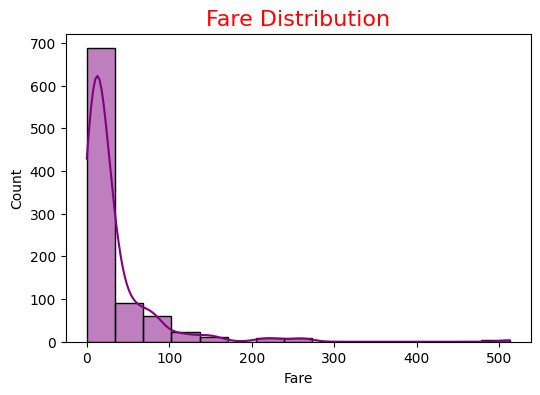

In [23]:
# Fare Distribution

plt.figure(figsize=(6,4))
sns.histplot(dataframe['Fare'],bins=15,kde = True , color = 'purple')
plt.title("Fare Distribution",fontsize = 16, color = 'red')

Fare data is highly skewed.

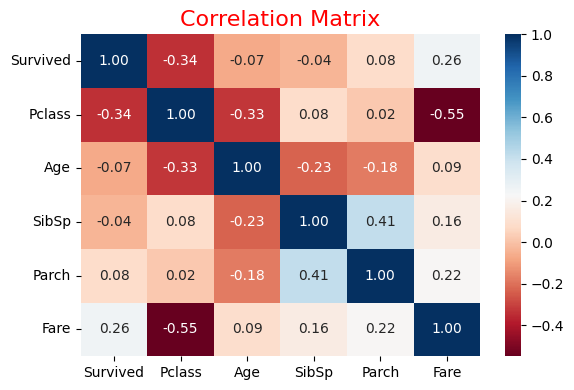

In [24]:
plt.figure(figsize=(6,4))
sns.heatmap(dataframe.drop(columns=['Sex','Embarked']).corr(), annot= True, cmap= 'RdBu', fmt= '.2f')
plt.title("Correlation Matrix", fontsize = 16 , color = 'red')
plt.tight_layout()
plt.show()

In [25]:
dataframe.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

**Encode Categorical Data**

In [26]:
dataframe["Sex"] = LabelEncoder().fit_transform(dataframe["Sex"])
dataframe["Embarked"] = LabelEncoder().fit_transform(dataframe['Embarked'])

In [27]:
dataframe.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [28]:
# loading or reading the data
dataframeTest = pd.read_csv("D:\\Work\\ExcelRCource\\Assignments\\7 Logistic Regression\\Titanic_test.csv")

In [29]:
dataframeTest.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [30]:
# Drop unnecessary columns
dataframeTest = dataframeTest.drop(columns=['PassengerId','Name','Ticket','Cabin'])

In [31]:
dataframeTest.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S


**Handle Missing Data**

In [32]:
#checking how many null values are there in the dataset using isna().
dataframeTest.isna().sum()

Pclass       0
Sex          0
Age         86
SibSp        0
Parch        0
Fare         1
Embarked     0
dtype: int64

In [33]:
# Fill Missing Values
dataframeTest["Age"] = dataframeTest['Age'].fillna(dataframeTest['Age'].mean())
dataframeTest['Fare'] = dataframeTest['Fare'].fillna(dataframeTest['Fare'].median())

Above, for fare column we have replaced its median value with null. Instead of mean we use median, because Fare has highly skewed data.

In [34]:
dataframeTest.isna().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [35]:
## Encode categorical variables

dataframeTest["Sex"] = LabelEncoder().fit_transform(dataframeTest["Sex"])
dataframeTest["Embarked"] = LabelEncoder().fit_transform(dataframeTest['Embarked'])

**Feature Selection**

In [36]:
X = dataframe.drop(columns =["Survived"], axis=1)
y = dataframe[['Survived']]

#X_test = dataframeTest.copy()
#y_test = dataframeTest[['Survived']]

In [37]:
X.shape

(891, 7)

In [38]:
y.shape

(891, 1)

In [39]:
# Split for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
# Train Logistic Regression
titanic_model = LogisticRegression(max_iter=1000)
titanic_model.fit(X_train, y_train)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [41]:
# Evaluate the Model
y_pred = titanic_model.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print(classification_report(y_val, y_pred))

Validation Accuracy: 0.8101
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [42]:
# Predict on Test Set
X_test = dataframeTest
X_test = X_test.reindex(columns=X.columns, fill_value=0) # Ensure columns match
test_predictions = titanic_model.predict(X_test)

In [43]:
# Predict on test data
test_predictions = titanic_model.predict(X_test)
dataframeTest['Survived'] = test_predictions

In [44]:
# Save result
#dataframeTest[['Survived']].to_csv('titanic_predictions.csv', index=False)
print("\nPredictions saved to titanic_predictions.csv")


Predictions saved to titanic_predictions.csv


**Results Summary**\
After running the code with your provided files:\
**Validation Accuracy:** $81.01\%$\
**Performance:** The model is particularly good at identifying survivors, with balanced precision and recall across both classes ($0$ for perished, $1$ for survived).\
**Predictions:** The final predictions for the Titanic_test.csv file have been generated and stored.

In [45]:
import joblib
# Assuming 'model' is your trained LogisticRegression object
joblib.dump(titanic_model, 'titanic_model.pkl')

['titanic_model.pkl']